In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import linearmodels as lm 
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import sys
import os

sys.path.append('../Scripts') 

#sys.path.append('C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/Scripts')

import Elasticities as el


## Functions

In [2]:
#Function to group data
def group_nlog (df: pd.DataFrame, group_cols: list):
    grouped_df = resample_nlog(df.groupby(group_cols))
    return grouped_df

#Resamples dataframe for frequency and calculates aggregates needed for calculating elasticities
def resample_nlog(df, freq='d'):
    resample_df = (df.resample(freq, on='date')
                     .agg(sales=('product_quantity', 'sum'), 
                          price=('unit_price', 'mean'), 
                          discount=('discount', 'mean'))
                    #.reset_index()
                    )
    resample_df['log_sales'] = np.log(resample_df['sales'] + 1) 
    resample_df['log_discount'] = np.log(resample_df['discount'] + 1)
    return(resample_df)

#Conducts a fixed effects regression
def fixed_reg(df):
    model = lm.PanelOLS.from_formula(
    'log_sales ~ log_discount + EntityEffects', 
    data=df
    )
    results = model.fit()
    return results

#Formats a scatter plot showing the relationship between discounts and sales
def plot_nformat(df):
     slope, intercept, r_value, p_value, std_err = stats.linregress(
     df['log_discount'], df['log_sales']
     )

     sns.set_style("whitegrid")
     plt.figure(figsize=(10, 6))

     g = sns.lmplot(
     data=df,
     x='log_discount', 
     y='log_sales',
     height=6,
     aspect=1.3,
     scatter_kws={'alpha': 0.6, 's': 60, 'color': 'steelblue'},
     line_kws={'color': 'red', 'linewidth': 2},
     ci=95
     )
     g.figure.set_size_inches(10, 5.6)
     plt.title(f'Log Discount vs Log Sales\n'
               f'y = {intercept:.3f} + {slope:.3f}x (R²={r_value**2:.3f})')
     plt.tight_layout()
     plt.show()

def create_lags (df, nlags, col_name):
    for n in range(1, nlags + 1):
        df[col_name + '_lag' + str(n)] = df[col_name].shift(n)
    return(df.dropna())



### Read data

In [3]:
clean_df = pd.read_csv('C:/Users/admin/Documents/1WBS/3Data_Cln_Stry/eniac_cleaning/data/processed/clean_df.csv',
                      parse_dates=['date', 'created_date'])

daily_df = resample_nlog(clean_df)
weekly_df = resample_nlog(clean_df, 'W')

## Overall regressions

In [4]:
daily_df_lags = create_lags(daily_df, 5, 'log_discount')

model = LinearRegression().fit(daily_df_lags[['log_discount', 'log_discount_lag1']], daily_df_lags['log_sales'])
print(model.coef_)

X = daily_df_lags[['log_discount', 'log_discount_lag1', 'log_discount_lag2', 'log_discount_lag3', 'log_discount_lag4', 'log_discount_lag5']]
y = daily_df_lags['log_sales']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# Print comprehensive results
print(model.summary())

[0.38039859 0.00365523]
                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     3.010
Date:                Wed, 26 Nov 2025   Prob (F-statistic):            0.00683
Time:                        12:48:00   Log-Likelihood:                -333.24
No. Observations:                 433   AIC:                             680.5
Df Residuals:                     426   BIC:                             709.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const         

## Plots

<Figure size 1000x600 with 0 Axes>

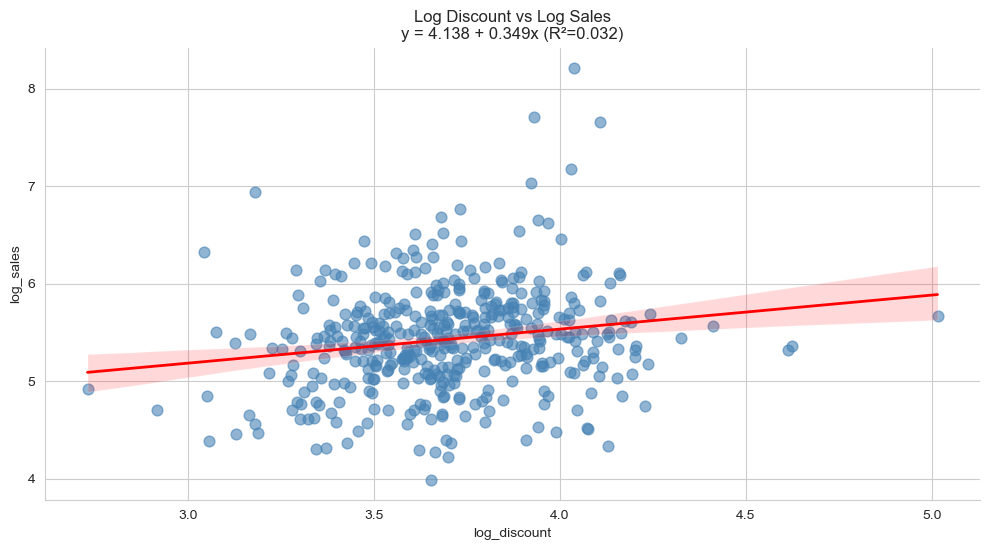

<Figure size 1000x600 with 0 Axes>

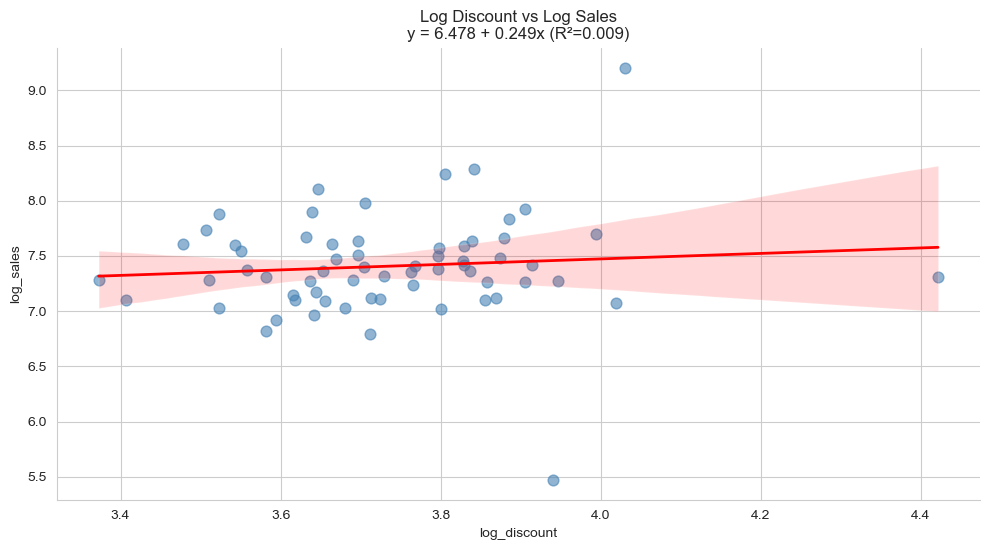

In [5]:
plot_nformat(daily_df)
plot_nformat(weekly_df)

## Regressions grouped by categories

### Grouped by brand

In [6]:
brand_elasticities = el.group_elasticities(clean_df, 'long', 'W')
brand_elasticities_d = el.group_elasticities(clean_df, 'long', 'd')

C:\Users\admin\AppData\Local\Temp\ipykernel_21780\1349352630.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=brand_elasticities.nlargest(10, 'Revenue').sort_values('Elasticity', ascending=False),


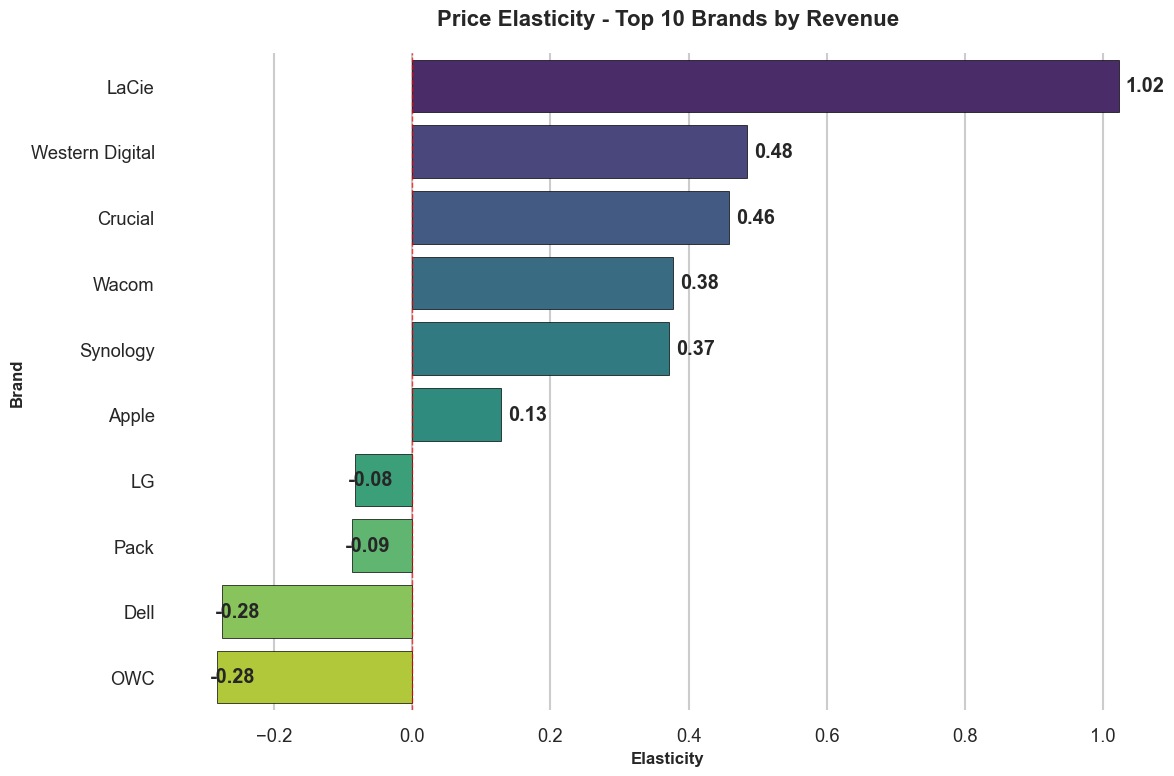

In [7]:


# Set style and context for better appearance
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.8)

# Sort by elasticity and create the plot
plt.figure(figsize=(12, 8))

ax = sns.barplot(data=brand_elasticities.nlargest(10, 'Revenue').sort_values('Elasticity', ascending=False),
            x='Elasticity',
            y='long',
            palette="viridis",
            edgecolor='black',
            linewidth=0.5)

# Customize the plot
plt.title('Price Elasticity - Top 10 Brands by Revenue', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Elasticity', fontsize=12, fontweight='bold')
plt.ylabel('Brand', fontsize=12, fontweight='bold')

# Add value labels on bars
for i, v in enumerate(brand_elasticities.nlargest(10, 'Revenue')
                      .sort_values('Elasticity', ascending=False)['Elasticity']):
    ax.text(v + 0.01 * (1 if v >= 0 else -1), i, 
            f'{v:.2f}', 
            va='center', 
            fontweight='bold')

# Add vertical line at x=0 for reference
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=1)

# Adjust layout
sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()


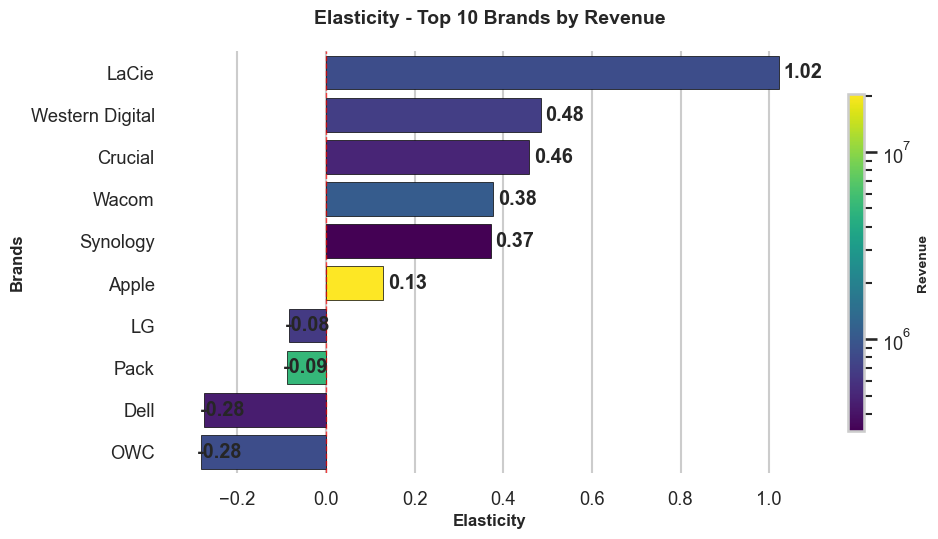

In [8]:
def bar_plot(df, x_col, y_col, group_name, nlarg_col, nlarg_num = 10):
    # Sort by elasticity and prepare data
    sorted_data = df.nlargest(nlarg_num, nlarg_col).sort_values(x_col, ascending=False)

    # Create the plot with color representing revenue on log scale
    plt.figure(figsize=(10, 5.625))

    ax = sns.barplot(data=sorted_data,
                x=x_col,
                y=y_col,
                hue=y_col,
                edgecolor='black',
                linewidth=0.5)

    # Create custom colors based on revenue (log scale)
    from matplotlib.colors import LogNorm

    # Get revenue values and apply log scale
    revenues = sorted_data[nlarg_col].values
    log_revenues = np.log10(revenues)  # Log transform

    # Normalize for colormap
    norm = LogNorm(vmin=revenues.min(), vmax=revenues.max())
    cmap = plt.cm.viridis

    # Update bar colors based on revenue
    for i, bar in enumerate(ax.patches):
        bar.set_facecolor(cmap(norm(revenues[i])))

    # Customize the plot
    plt.title(f'{x_col} - Top 10 {group_name} by {nlarg_col}', 
            fontsize=14, fontweight='bold', pad=20)
    plt.xlabel(x_col, fontsize=12, fontweight='bold')
    plt.ylabel(group_name, fontsize=12, fontweight='bold')

    # Add value labels on bars
    for i, (v, rev) in enumerate(zip(sorted_data[x_col], sorted_data[nlarg_col])):
        ax.text(v + 0.01 * (1 if v >= 0 else -1), i, 
                f'{v:.2f}', 
                va='center', 
                fontweight='bold')

    # Add vertical line at x=0 for reference
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=1)

    # Add colorbar to show revenue scale
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.8)
    cbar.set_label(nlarg_col, fontsize=10, fontweight='bold')

    # Adjust layout
    sns.despine(left=True, bottom=True)
    plt.tight_layout()

    plt.show()

bar_plot(brand_elasticities, 'Elasticity', 'long', 'Brands', 'Revenue', 10)

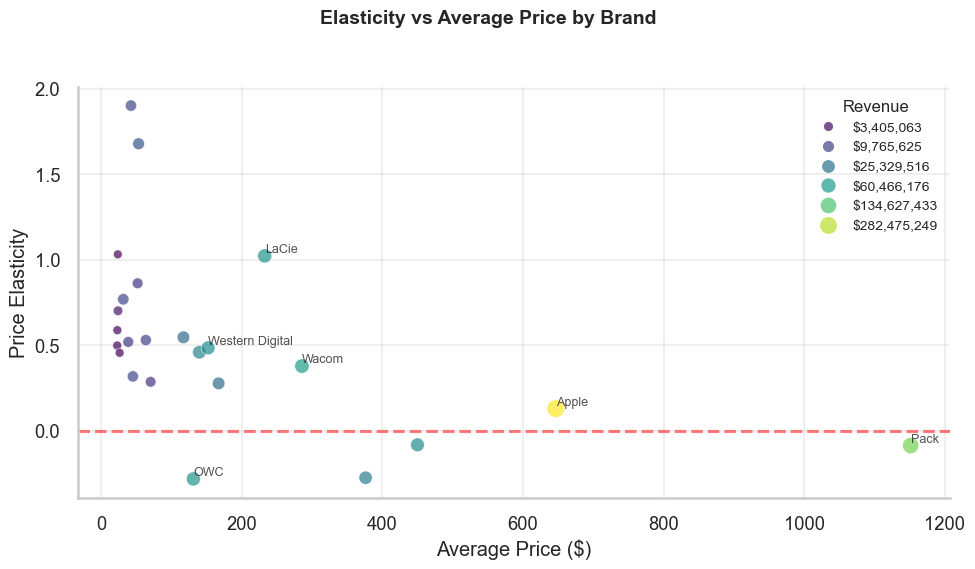

In [9]:


def scatter_plot(df, x_col, y_col, hue_col, group_name, label_col = None, loc = 'upper right'):
# Create plot with log-transformed revenue
    g = sns.relplot(
        data=df,
        x=x_col,
        y=y_col,
        size=np.log10(df[hue_col]),
        hue=np.log10(df[hue_col]),
        palette='viridis',
        alpha=0.7
    )

    # Add title and labels
    g.figure.suptitle(f'{y_col.replace('_', ' ')} vs {x_col.replace('_', ' ')} by {group_name.replace('_', ' ')}', fontsize=14, fontweight='bold', y=1.02)
    g.set_axis_labels('Average Price ($)', 'Price Elasticity')
    g.figure.set_size_inches(10, 5.6)

    # Get top brands for labeling
    top_brands = df.nlargest(6, hue_col)

    # Add labels
    if label_col is not None:
        for idx, row in top_brands.iterrows():
            g.ax.text(
                row[x_col] + 0.02,
                row[y_col] + 0.02,
                row[label_col],
                fontsize=9,
                alpha=0.8
            )

    # Improve styling
    g.ax.grid(True, alpha=0.3)
    g.ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

    # Update legend labels to show actual revenue values
    if g._legend:
        # Get current legend handles and labels
        handles, labels = g.ax.get_legend_handles_labels()
        # Convert log values back to readable revenue numbers
        new_labels = [f"${float(label)**10:,.0f}" for label in labels]
        g.ax.legend(
                handles, 
                new_labels, 
                title=hue_col,
                loc=loc,  # Or choose another location: 'upper left', 'lower right', etc.
                frameon=False,  # Remove border
                fancybox=False,  # Remove rounded corners
                fontsize=10,
                title_fontsize=12
            )

    #g.ax.legend_.remove()
    g._legend.remove()
    
    return g
    

brand_elas_price_g = scatter_plot(brand_elasticities[brand_elasticities.Sales > 1000], 'Average_Price', 'Elasticity', 'Revenue', 'Brand', 'long')
plt.tight_layout()

plt.show()

### Brand cost benefit analysis

In [10]:
def check_signif (df):
    conditions = [
        (df['P_value'] < 0.05) & (df['Elasticity'] > 0),
        (df['P_value'] < 0.05) & (df['Elasticity'] <= 0),
        (df['P_value'] >= 0.05)
    ]

    choices = ['Positive', 'Negative', 'Not significant']

    return np.select(conditions, choices, default='Not significant')

brand_elasticities_d['significant'] = check_signif(brand_elasticities_d)
brand_elasticities['significant'] = check_signif(brand_elasticities)

### Grouped by price category

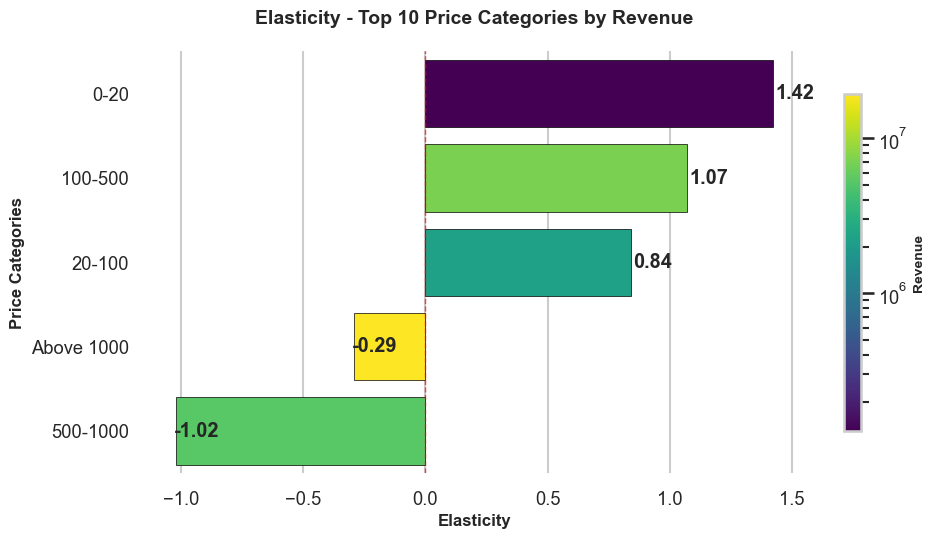

In [11]:
price_cat_groups = el.group_elasticities(clean_df, 'price_category', 'W')
bar_plot(price_cat_groups, 'Elasticity', 'price_category', 'Price Categories', 'Revenue', 10)

### Grouped by type + price

In [12]:
clean_df['type_price'] = clean_df.type.astype(str) + '/' + clean_df.price.astype(str)
#a = clean_df.type_price.value_counts()
typeprice_cat_groups = el.group_elasticities(clean_df, 'type_price', 'W')




In [13]:
typeprice_cat_groups_d = el.group_elasticities(clean_df, 'type_price', 'd')

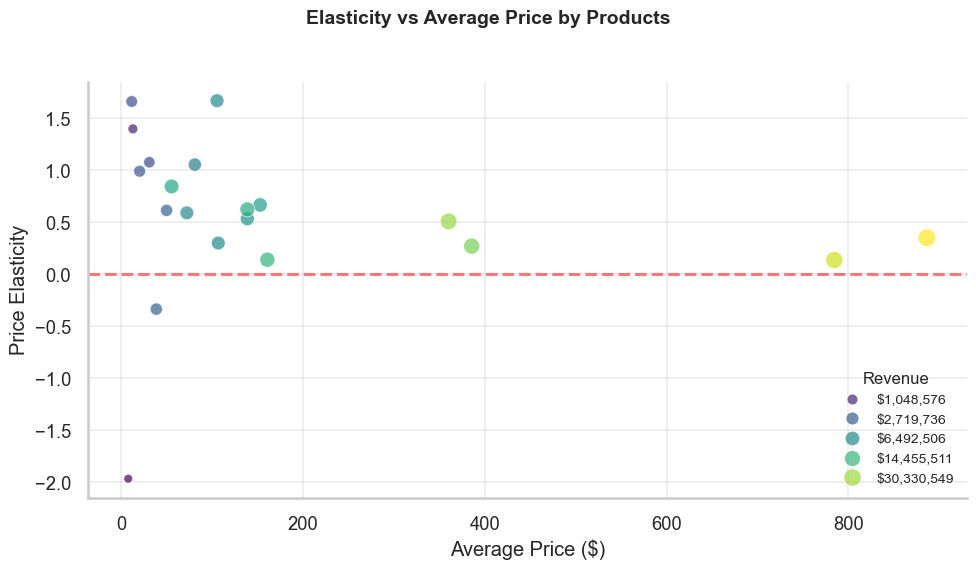

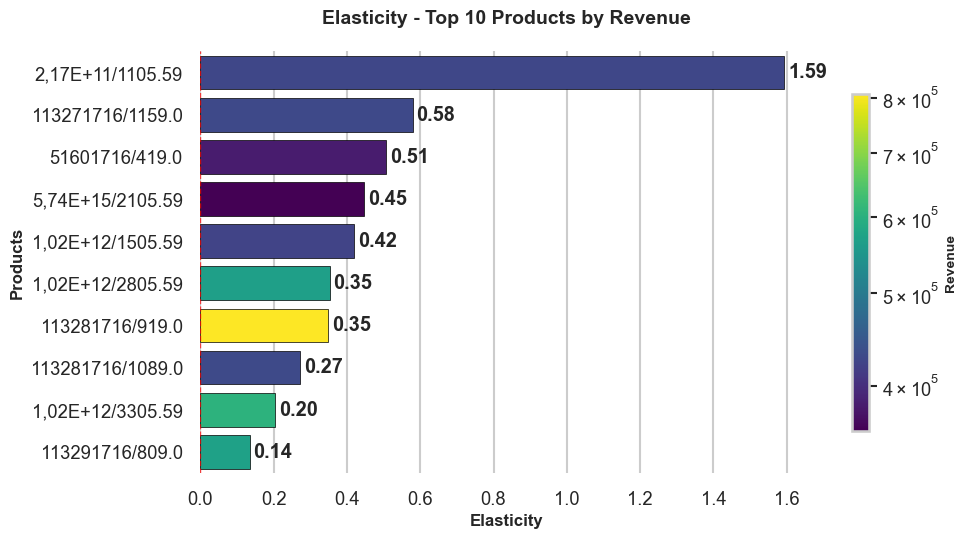

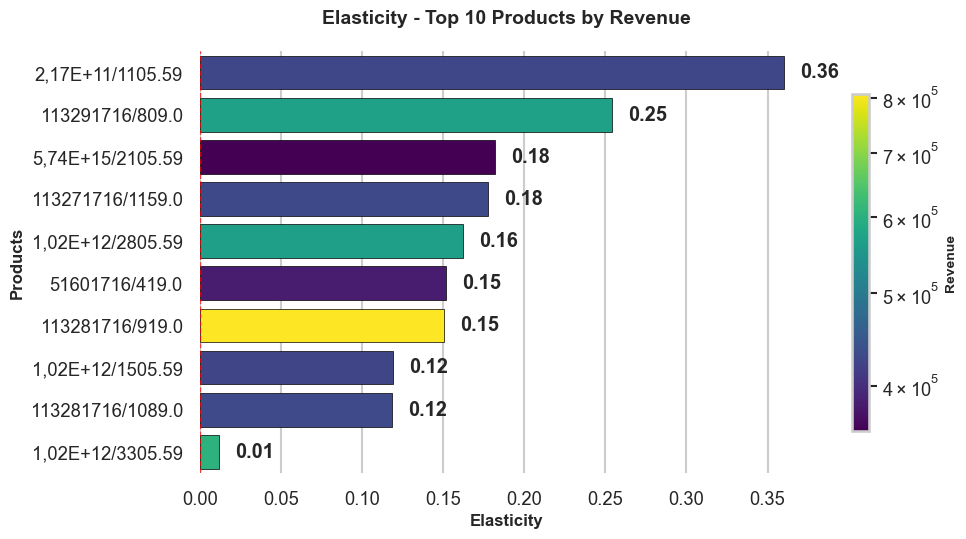

In [14]:
typeprice_elas_price_g = scatter_plot(typeprice_cat_groups[typeprice_cat_groups.Sales > 500], 'Average_Price', 'Elasticity', 'Revenue', 'Products', loc='lower right')
plt.tight_layout()
plt.show()

bar_plot(typeprice_cat_groups, 'Elasticity', 'type_price', 'Products', 'Revenue', 10)
bar_plot(typeprice_cat_groups_d, 'Elasticity', 'type_price', 'Products', 'Revenue', 10)

### Grouped by price category (fixed regressions)

In [15]:
grouped_p_category = group_nlog(clean_df, ['price_category'])
print(fixed_reg(grouped_p_category))




                          PanelOLS Estimation Summary                           
Dep. Variable:              log_sales   R-squared:                        0.0099
Estimator:                   PanelOLS   R-squared (Between):              0.3299
No. Observations:                2186   R-squared (Within):               0.0099
Date:                Wed, Nov 26 2025   R-squared (Overall):              0.3203
Time:                        12:51:34   Log-likelihood                   -2063.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      21.748
Entities:                           5   P-value                           0.0000
Avg Obs:                       437.20   Distribution:                  F(1,2180)
Min Obs:                       434.00                                           
Max Obs:                       438.00   F-statistic (robust):             21.748
                            

c:\Users\admin\anaconda3\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


In [ ]:
print(model.params.log_discount)
print(model.pvalues.log_discount)

0.352732154629074
0.0007533952424831877


Type:            RegressionResultsWrapper
String form:     <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x000001BD6F3EE900>
File:            c:\users\admin\anaconda3\lib\site-packages\statsmodels\regression\linear_model.py
Docstring:      
Results class for for an OLS model.

Parameters
----------
model : RegressionModel
    The regression model instance.
params : ndarray
    The estimated parameters.
normalized_cov_params : ndarray
    The normalized covariance parameters.
scale : float
    The estimated scale of the residuals.
cov_type : str
    The covariance estimator used in the results.
cov_kwds : dict
    Additional keywords used in the covariance specification.
use_t : bool
    Flag indicating to use the Student's t in inference.
**kwargs
    Additional keyword arguments used to initialize the results.

See Also
--------
RegressionResults
    Results store for WLS and GLW models.

Notes
-----
Most of the methods and attributes are inherited from Regre

In [17]:
df = grouped_p_category.reset_index()
group_col = 'price_category'
elasticities_df = pd.DataFrame(columns=[group_col, 'Elasticity', 'P_value'])

def elasticity_calc(df, group_col):
    elasticities_df = pd.DataFrame(columns=[group_col, 'Elasticity', 'P_value'])
    for i in df[group_col].unique():
        subset = df[df[group_col] == i].dropna()
        X = subset[['log_discount']]
        y = subset['log_sales']
        X = sm.add_constant(X)
        model = sm.OLS(y, X).fit()
        #print(i)
        #print(model.summary())
        elasticities_df.loc[len(elasticities_df)] = [i, model.params.log_discount, model.pvalues.log_discount]
    return elasticities_df

### Grouped by brand and price category

In [18]:
grouped_df = group_nlog(clean_df, ['long'])
print(fixed_reg(grouped_df))

                          PanelOLS Estimation Summary                           
Dep. Variable:              log_sales   R-squared:                        0.0303
Estimator:                   PanelOLS   R-squared (Between):              0.4384
No. Observations:               22315   R-squared (Within):               0.0303
Date:                Wed, Nov 26 2025   R-squared (Overall):              0.3291
Time:                        12:51:36   Log-likelihood                -1.695e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      691.46
Entities:                         179   P-value                           0.0000
Avg Obs:                       124.66   Distribution:                 F(1,22135)
Min Obs:                       1.0000                                           
Max Obs:                       438.00   F-statistic (robust):             691.46
                            

c:\Users\admin\anaconda3\Lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


### Regressions by top products